# Final Project in Python: One-Week Project on Customer Dataset

This notebook is developed for the final project of the Python course and uses the provided dataset `bank_customer_analytics.csv`. The main goal of the project is to prepare the customer dataset for a future Machine Learning model by following a structured data processing pipeline.

The main target variable of the analysis is the `Churn` column, which indicates whether a customer left the bank or not, so the project is treated as a customer churn analysis problem. The dataset also includes demographic, financial, account-related, and credit-related information that may help explain customer behavior.

The purpose of this notebook is not only to explore the dataset, but also to gradually transform it from raw data into a clean and useful final dataset. For this reason, the work follows a pipeline approach:

1. Raw Data
2. Data Inspection
3. Missing Value Handling
4. EDA and Visualization
5. Outlier Handling
6. Feature Selection
7. Final Dataset

Each step in the list above builds on the previous one. First, the raw data is loaded and inspected. Then, possible quality issues such as missing values, incorrect data types, and outliers are examined and handled. After that, exploratory data analysis is performed to understand distributions, relationships, and possible patterns related to churn. Finally, basic feature selection techniques are applied so that the final exported dataset contains the most useful variables for future modeling. This pipeline ensures that the final dataset is consistent, informative, and suitable for later machine learning applications.

The implementation follows an Object-Oriented Programming approach. The class `BankCustomerDataAnalyzer` is used to organize the code into reusable methods for loading, inspecting, cleaning, visualizing, selecting features, and saving the processed dataset.

---Some required libraries are used throughout the whole analysis and they are imported in the section below:

## 1. Needed Libraries

This section imports the libraries required for data handling, numerical calculations, visualization, preprocessing, feature selection. These are used throughout the whole analysis and provide all the necessary tools to efficiently manipulate the dataset, perform exploratory data analysis (EDA), implement data cleaning techniques, apply feature selection methods, and evaluate machine learning models. By organizing all dependencies at the beginning, the workflow can remain reproducible, structured, and more easy to follow.

In [134]:
# Main library for data handling (data manipulation and analysis)
import pandas as pd

# Needed for numerical operations and calculations
import numpy as np

# Basic plotting library (feature selection and preprocessing techniques)
import matplotlib.pyplot as plt

# Library built on matplotlib for advanced visualizations
import seaborn as sns

# Needed to create paths from file name string input
from pathlib import Path

# Used to display DataFrames clearly inside the notebook
from IPython.display import display

# Feature selection methods used in the project
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif

# Used to convert categorical variables into numerical labels for Information Gain
from sklearn.preprocessing import LabelEncoder

# Reproducibility setting, controls randomnes of algorithm
RANDOM_STATE = 42

## 2. System Design: BankCustomerDataAnalyzer Class

Following the OOP architecture that was also implemented in previous projects, the class `BankCustomerDataAnalyzer` will be responsible for the main steps of the data preparation pipeline. It will load the dataset into a DataFrame based on a given file name and provide methods for inspecting the data, analysing the target variable, handling missing values, cleaning categorical values, exploring numerical and categorical characteristics, visualizing distributions and relationships, detecting and handling outliers, applying feature selection and exporting the final processed dataset.

The attributes of the `BankCustomerDataAnalyzer` class are  the following: 
- `file_name`: stores the name of the CSV file,
- `target_column`: stores the target variable,
- `id_column`: stores the customer identifier column,
- `data`: stores the full raw dataset,
- `processed_data`: stores the dataset after cleaning and preprocessing,
- `final_data`: stores the final dataset after feature selection,
- `report`: stores important results from the analysis

This design allows for a more organized and structured workflow, while also preserving the original dataset. As a result, it provides the flexibility to compare the raw and processed data at any stage of the analysis, validate transformations, and ensure that no important information is unintentionally lost during preprocessing. Furthermore, it enhances traceability and reproducibility, facilitates debugging, and allows for experimentation with different preprocessing strategies.

A potential drawback of this approach is the increased memory usage, as both the raw and processed datasets are stored simultaneously. However, this can be acceptable for the specific dataset because its size is relatively small and the analytical benefits of this approach are more important.

Below is the full python code for the class, with insightful comments throughout. In the next chapter where all these functions will be executed, implementing the pipeline approach aforementioned, each step will be analyzed in depth, since it is not feasible to have parts of the class in different cells of this notebook to provide further analysis in this segment. 

In [135]:
class BankCustomerDataAnalyzer:
    """
    Represents an analyzer for bank customers' data.

    Attributes:
        file_name (Path): The name of the CSV file containing the dataset.
        target_column (str): The column representing the target variable.
        id_column (str): The column representing the unique customer ID.
        data (pd.DataFrame | None): The full dataset loaded from the CSV file.
        processed_data (pd.DataFrame | None): The dataset after cleaning and preprocessing.
        final_data (pd.DataFrame | None): The final dataset after feature selection.
        report (dict): A dictionary storing summary information from the analysis.
    """

    def __init__(self, file_name: str, target_column: str = "Churn", id_column: str = "CustomerID") -> None:
        """
        Initialize a BankCustomerDataAnalyzer object.

        Args:
            file_name (str): The name of the CSV file containing the dataset.
            target_column (str): The name of the target column. Defaults to "Churn".
            id_column (str): The name of the customer ID column. Defaults to "CustomerID".

        Returns:
            None
        """
        self.file_name = Path(file_name)
        self.target_column = target_column
        self.id_column = id_column

        self.data = None
        self.processed_data = None
        self.final_data = None
        self.report = {}

    def load_data(self) -> pd.DataFrame:
        """
        Load the dataset from the CSV file and store it in the data attribute.

        Args:
            None

        Returns:
            pd.DataFrame: The loaded dataset.
        """
        path = Path(self.file_name)

        if len(path.parts) != 1:
            raise ValueError("Please provide only the filename, not a path.")

        matches = list(Path.cwd().rglob(path.name))

        if len(matches) == 0:
            search_roots = [Path.cwd(), Path("/mnt/data")]
            matches = []

            for root in search_roots:
                if root.exists():
                    matches.extend(list(root.rglob(path.name)))

            matches = list(dict.fromkeys(matches))

        if len(matches) == 0:
            raise FileNotFoundError(f"No file named '{path.name}' was found.")

        if len(matches) > 1:
            raise FileExistsError(
                f"Multiple files named '{path.name}' were found:\n"
                + "\n".join(str(match.resolve()) for match in matches)
                + "\nPlease keep only one file with that name or rename the duplicates."
            )

        self.data = pd.read_csv(matches[0])
        self.report["loaded_shape"] = self.data.shape

        print("Data loaded successfully!")

        return self.data

    def inspect_data(self) -> None:
        """
        Display a general overview of the loaded dataset.

        Args:
            None

        Returns:
            None
        """
        self._require_data()

        print('\n---------------------------------------------------------------------------------------------------\n')
        print("FIRST 5 ROWS:")
        display(self.data.head())
        print('\n---------------------------------------------------------------------------------------------------\n')
        print("SHAPE (rows, columns):")
        print(self.data.shape)
        print('\n---------------------------------------------------------------------------------------------------\n')
        print("COLUMN NAMES:")
        display(self.data.columns.tolist())
        print('\n---------------------------------------------------------------------------------------------------\n')
        print("INFO:")
        self.data.info()
        print('\n---------------------------------------------------------------------------------------------------\n')
        print("BASIC NUMERIC STATISTICS:")
        display(self.data.describe(include="number").T)
        print('\n---------------------------------------------------------------------------------------------------\n')
        print("BASIC CATEGORICAL STATISTICS:")
        display(self.data.describe(include=["object", "string", "category"]).T)
        print('\n---------------------------------------------------------------------------------------------------\n')
        print("UNIQUE VALUES:")
        display(self.data.nunique().sort_values(ascending=False))

    def analyze_target(self) -> pd.DataFrame:
        """
        Analyze the distribution of the target column.

        Args:
            None

        Returns:
            pd.DataFrame: A summary containing target counts and percentages.
        """
        self._require_data()
        self._require_column(self.target_column, self.data)

        target_summary = pd.DataFrame({
            "count": self.data[self.target_column].value_counts(),
            "percentage": self.data[self.target_column].value_counts(normalize=True).mul(100).round(2)
        })

        print("TARGET SUMMARY:")
        display(target_summary)

        plt.figure(figsize=(7, 5))
        sns.countplot(data=self.data, x=self.target_column, color="steelblue")
        plt.title(f"Distribution of Target Variable: {self.target_column}")
        plt.xlabel(self.target_column)
        plt.ylabel("Customer Count")
        plt.show()

        self.report["target_summary"] = target_summary

        return target_summary

    def analyze_missing_values(self) -> pd.DataFrame:
        """
        Analyze missing values in the loaded dataset.

        Args:
            None

        Returns:
            pd.DataFrame: A summary of missing counts and missing percentages.
        """
        self._require_data()

        missing_summary = pd.DataFrame({
            "missing_count": self.data.isna().sum(),
            "missing_percentage": self.data.isna().mean().mul(100).round(2),
        }).sort_values("missing_percentage", ascending=False)

        print("MISSING SUMMARY:")
        display(missing_summary)

        plt.figure(figsize=(10, 5))
        sns.barplot(
            x=missing_summary.index,
            y=missing_summary["missing_percentage"],
            color="steelblue"
        )
        plt.title("Missing Values by Column")
        plt.xlabel("Column")
        plt.ylabel("Missing Percentage")
        plt.xticks(rotation=45)
        plt.show()

        self.report["missing_summary"] = missing_summary

        return missing_summary

    def handle_missing_values(self, drop_threshold: float = 0.40) -> pd.DataFrame:
        """
        Handle missing values by dropping highly missing columns and filling remaining values.

        Args:
            drop_threshold (float): The maximum allowed missing-value ratio before a column is dropped.
                Defaults to 0.40.

        Returns:
            pd.DataFrame: The dataset after handling missing values.
        """
        self._require_data()

        df = self.data.copy()

        missing_ratio = df.isna().mean()
        columns_to_drop = missing_ratio[missing_ratio > drop_threshold].index.tolist()

        df = df.drop(columns=columns_to_drop)

        numeric_columns = df.select_dtypes(include="number").columns
        categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns

        for column in numeric_columns:
            df[column] = df[column].fillna(df[column].median())

        for column in categorical_columns:
            mode_values = df[column].mode()
            fill_value = mode_values.iloc[0] if not mode_values.empty else "unknown"
            df[column] = df[column].fillna(fill_value)

        self.processed_data = df
        self.report["dropped_missing_columns"] = columns_to_drop
        self.report["missing_after_imputation"] = int(df.isna().sum().sum())

        print("Missing value handling completed.")
        print(f"Columns dropped because of missingness: {columns_to_drop}")
        print(f"Remaining missing values: {self.report['missing_after_imputation']}")

        return self.processed_data

    def clean_categorical_values(self) -> pd.DataFrame:
        """
        Clean categorical columns by converting values to lowercase and removing extra spaces.

        Args:
            None

        Returns:
            pd.DataFrame: The dataset after cleaning categorical values.
        """
        self._require_processed_data()

        df = self.processed_data.copy()
        categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns

        for column in categorical_columns:
            df[column] = df[column].astype(str).str.lower().str.strip()

        self.processed_data = df

        print("Categorical value cleaning completed.")

        return self.processed_data

    def explore_data_characteristics(self) -> None:
        """
        Display numerical and categorical column information.

        Args:
            None

        Returns:
            None
        """
        self._require_processed_data()

        numeric_columns = self.processed_data.select_dtypes(include="number").columns.tolist()
        categorical_columns = self.processed_data.select_dtypes(include=["object", "string", "category"]).columns.tolist()

        print("Numerical columns:")
        display(numeric_columns)

        print("Categorical columns:")
        display(categorical_columns)

        for column in categorical_columns:
            print(f"\n{column}:")
            display(self.processed_data[column].value_counts())

        self.report["numeric_columns"] = numeric_columns
        self.report["categorical_columns"] = categorical_columns

    def plot_numeric_distributions(self) -> None:
        """
        Plot histograms for all numerical columns using subplots.

        Args:
            None

        Returns:
            None
        """
        self._require_processed_data()

        numeric_columns = self.processed_data.select_dtypes(include="number").columns
        n = len(numeric_columns)

        if n == 0:
            print("No numerical columns available for plotting.")
            return

        n_cols = 3
        n_rows = (n + n_cols - 1) // n_cols

        plt.figure(figsize=(5 * n_cols, 4 * n_rows))

        for i, column in enumerate(numeric_columns, 1):
            plt.subplot(n_rows, n_cols, i)
            sns.histplot(data=self.processed_data, x=column, kde=True, color="steelblue")

            plt.title(column)
            plt.xlabel(column)
            plt.ylabel("Frequency")
            plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    def plot_categorical_distributions(self, max_categories: int = 20) -> None:
        """
        Plot bar charts for categorical columns using subplots.

        Args:
            max_categories (int): The maximum number of categories to display for each column.
                Defaults to 20.

        Returns:
            None
        """
        self._require_processed_data()

        categorical_columns = self.processed_data.select_dtypes(include=["object", "string", "category"]).columns
        categorical_columns = [col for col in categorical_columns if col != self.id_column]

        n = len(categorical_columns)

        if n == 0:
            print("No categorical columns available for plotting.")
            return

        n_cols = 3
        n_rows = (n + n_cols - 1) // n_cols

        plt.figure(figsize=(5 * n_cols, 4 * n_rows))

        for i, column in enumerate(categorical_columns, 1):
            counts = self.processed_data[column].value_counts().head(max_categories)

            plt.subplot(n_rows, n_cols, i)
            sns.barplot(x=counts.index, y=counts.values, color="steelblue")

            plt.title(column)
            plt.xlabel(column)
            plt.ylabel("Count")
            plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    def plot_target_relationships(self) -> None:
        """
        Plot relationships between the target column and other columns using subplots.

        Args:
            None

        Returns:
            None
        """
        self._require_processed_data()
        self._require_column(self.target_column, self.processed_data)

        numeric_columns = self.processed_data.select_dtypes(include="number").columns.tolist()
        categorical_columns = self.processed_data.select_dtypes(
            include=["object", "string", "category"]
        ).columns.tolist()

        plots = []

        for column in numeric_columns:
            if column != self.target_column:
                plots.append(("numeric", column))

        for column in categorical_columns:
            if column not in [self.target_column, self.id_column]:
                plots.append(("categorical", column))

        n = len(plots)

        if n == 0:
            print("No columns available for target relationship plotting.")
            return

        n_cols = 3
        n_rows = (n + n_cols - 1) // n_cols

        plt.figure(figsize=(5 * n_cols, 4 * n_rows))

        for i, (col_type, column) in enumerate(plots, 1):
            plt.subplot(n_rows, n_cols, i)

            if col_type == "numeric":
                sns.boxplot(
                    data=self.processed_data,
                    x=self.target_column,
                    y=column,
                    color="steelblue"
                )
                plt.title(f"{column} by {self.target_column}")
                plt.xlabel(self.target_column)
                plt.ylabel(column)

            else:
                crosstab = pd.crosstab(
                    self.processed_data[column],
                    self.processed_data[self.target_column],
                    normalize="index",
                )

                crosstab.plot(kind="bar", ax=plt.gca())
                plt.title(f"{self.target_column} by {column}")
                plt.ylabel("Proportion")
                plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    def plot_correlation_heatmap(self) -> None:
        """
        Plot a correlation heatmap for numerical columns.

        Args:
            None

        Returns:
            None
        """
        self._require_processed_data()

        numeric_df = self.processed_data.select_dtypes(include="number")

        if numeric_df.shape[1] < 2:
            print("Not enough numerical columns for correlation analysis.")
            return

        plt.figure(figsize=(12, 8))
        sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Correlation Heatmap")
        plt.show()

    def detect_outliers(self) -> pd.DataFrame:
        """
        Detect outliers in numerical columns using the IQR method.

        Args:
            None

        Returns:
            pd.DataFrame: A summary of outlier counts, percentages, and bounds.
        """
        self._require_processed_data()

        numeric_columns = self.processed_data.select_dtypes(include="number").columns
        outlier_summary = []

        for column in numeric_columns:
            if column == self.target_column:
                continue

            q1 = self.processed_data[column].quantile(0.25)
            q3 = self.processed_data[column].quantile(0.75)
            iqr = q3 - q1

            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            outlier_count = (
                (self.processed_data[column] < lower_bound)
                | (self.processed_data[column] > upper_bound)
            ).sum()

            outlier_summary.append(
                {
                    "column": column,
                    "outlier_count": int(outlier_count),
                    "outlier_percentage": round(
                        outlier_count / len(self.processed_data) * 100, 2
                    ),
                    "lower_bound": lower_bound,
                    "upper_bound": upper_bound,
                }
            )

        outlier_summary = pd.DataFrame(outlier_summary)

        print("OUTLIER SUMMARY:")
        display(outlier_summary)

        self.report["outlier_summary"] = outlier_summary

        return outlier_summary

    def handle_outliers(self, exclude_binary: bool = True) -> pd.DataFrame:
        """
        Handle outliers in numerical columns using IQR clipping.

        Args:
            exclude_binary (bool): Whether to skip binary numerical columns.
                Defaults to True.

        Returns:
            pd.DataFrame: The dataset after outlier handling.
        """
        self._require_processed_data()

        df = self.processed_data.copy()
        numeric_columns = df.select_dtypes(include="number").columns

        clipped_columns = []

        for column in numeric_columns:
            if column == self.target_column:
                continue

            if exclude_binary and df[column].nunique() <= 2:
                continue

            q1 = df[column].quantile(0.25)
            q3 = df[column].quantile(0.75)
            iqr = q3 - q1

            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            original_values = df[column].copy()
            df[column] = df[column].clip(lower_bound, upper_bound)

            if not original_values.equals(df[column]):
                clipped_columns.append(column)

        self.processed_data = df
        self.report["clipped_outlier_columns"] = clipped_columns

        print(f"Outlier handling completed. Clipped columns: {clipped_columns}")

        return self.processed_data
    
    def select_features(
        self,
        correlation_threshold: float = 0.80,
        variance_threshold: float = 0.01,
        use_information_gain: bool = True,
        min_information_gain: float = 0.0
    ) -> pd.DataFrame:
        """
        Select features using variance filtering, correlation filtering, and optional information gain.
    
        Args:
            correlation_threshold (float): The maximum allowed correlation between features.
                Defaults to 0.80.
            variance_threshold (float): The minimum variance required for a feature.
                Defaults to 0.01.
            use_information_gain (bool): Whether to use information gain for feature ranking.
                Defaults to True.
            min_information_gain (float): The minimum information gain score required for a feature to be kept.
                Defaults to 0.0.
    
        Returns:
            pd.DataFrame: The final dataset after feature selection.
        """
        self._require_processed_data()
        self._require_column(self.target_column, self.processed_data)
    
        df = self.processed_data.copy()
    
        if df[self.target_column].isna().any():
            raise ValueError("Target column contains missing or unmapped values.")
    
        columns_to_remove = [self.target_column]
    
        if self.id_column in df.columns:
            columns_to_remove.append(self.id_column)
    
        x_original = df.drop(columns=columns_to_remove)
        y = df[self.target_column]
    
        x = x_original.copy()
        label_encoders = {}
    
        categorical_columns = x.select_dtypes(
            include=["object", "string", "category"]
        ).columns.tolist()
    
        for column in categorical_columns:
            encoder = LabelEncoder()
            x[column] = encoder.fit_transform(x[column].astype(str))
            label_encoders[column] = encoder
    
        if y.dtype == "object" or y.dtype.name in ["string", "category"]:
            target_encoder = LabelEncoder()
            y_encoded = target_encoder.fit_transform(y.astype(str))
        else:
            target_encoder = None
            y_encoded = y
    
        selector = VarianceThreshold(threshold=variance_threshold)
        selector.fit(x)
    
        low_variance_columns = x.columns[~selector.get_support()].tolist()
        x = x.drop(columns=low_variance_columns)
    
        if x.shape[1] == 0:
            raise ValueError("No features remain after variance thresholding.")
    
        corr_matrix = x.corr().abs()
    
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
    
        high_corr_columns = [
            column
            for column in upper_triangle.columns
            if any(upper_triangle[column] > correlation_threshold)
        ]
    
        x = x.drop(columns=high_corr_columns)
    
        if x.shape[1] == 0:
            raise ValueError("No features remain after correlation filtering.")
    
        mutual_info_scores = None
    
        if use_information_gain:
            discrete_features = np.array([
                column in categorical_columns for column in x.columns
            ])
    
            mutual_info_scores = pd.Series(
                mutual_info_classif(
                    x,
                    y_encoded,
                    discrete_features=discrete_features,
                    random_state=RANDOM_STATE
                ),
                index=x.columns,
            ).sort_values(ascending=False)
    
            print("INFORMATION GAIN SCORES:")
            display(mutual_info_scores.to_frame(name="information_gain"))
    
            plt.figure(figsize=(10, 5))
            sns.barplot(
                x=mutual_info_scores.values,
                y=mutual_info_scores.index,
                color="steelblue"
            )
            plt.title("Feature Importance Based on Information Gain")
            plt.xlabel("Information Gain")
            plt.ylabel("Feature")
            plt.show()
    
            selected_columns = mutual_info_scores[
                mutual_info_scores > min_information_gain
            ].index.tolist()
    
            if len(selected_columns) == 0:
                raise ValueError(
                    "No features selected. Try lowering min_information_gain."
                )
    
            x = x[selected_columns]
    
        final_df = pd.concat(
            [
                x.reset_index(drop=True),
                pd.Series(y.values, name=self.target_column)
            ],
            axis=1
        )
    
        self.final_data = final_df
        self.processed_data = final_df
    
        self.report["low_variance_columns"] = low_variance_columns
        self.report["high_correlation_columns"] = high_corr_columns
        self.report["information_gain_scores"] = mutual_info_scores
        self.report["label_encoders"] = label_encoders
        self.report["target_encoder"] = target_encoder
        self.report["selected_features"] = x.columns.tolist()
        self.report["final_shape"] = final_df.shape
    
        print("Feature selection completed.")
        print(f"Low-variance columns removed: {low_variance_columns}")
        print(f"Highly correlated columns removed: {high_corr_columns}")
        print(f"Selected final features: {x.columns.tolist()}")
        print(f"Final dataset shape: {final_df.shape}")
    
        return self.final_data

    def save_processed_data(self, filename: str = "processed_bank_customer_data.csv") -> None:
        """
        Save the processed or final dataset to a CSV file.

        Args:
            filename (str): The name of the output CSV file.
                Defaults to "processed_bank_customer_data.csv".

        Returns:
            None
        """
        if self.final_data is not None:
            self.final_data.to_csv(filename, index=False)
            print(f"Final dataset saved successfully as: {filename}")
        elif self.processed_data is not None:
            self.processed_data.to_csv(filename, index=False)
            print(f"Processed dataset saved successfully as: {filename}")
        else:
            raise ValueError("No processed data available to save.")

    def get_report(self) -> dict:
        """
        Return the analysis report dictionary.

        Args:
            None

        Returns:
            dict: The report dictionary containing analysis and preprocessing details.
        """
        return self.report

    def _require_data(self) -> None:
        """
        Check whether the dataset has been loaded.

        Args:
            None

        Returns:
            None
        """
        if self.data is None:
            raise ValueError("No data loaded. Run load_data() first.")

    def _require_processed_data(self) -> None:
        """
        Check whether processed data is available.

        Args:
            None

        Returns:
            None
        """
        if self.processed_data is None:
            raise ValueError("No processed data available.")

    @staticmethod
    def _require_column(column: str, df: pd.DataFrame) -> None:
        """
        Check whether a column exists in a DataFrame.

        Args:
            column (str): The name of the column to check.
            df (pd.DataFrame): The DataFrame to check.

        Returns:
            None
        """
        if column not in df.columns:
            raise ValueError(f"Column '{column}' was not found.")

## 3. Data Processing Pipeline Execution and Analysis

In this section, the complete data processing pipeline is executed step by step. Each step corresponds to a specific part of the EDA and preprocessing process: loading the raw data, understanding the target variable, analyzing missing values, cleaning the dataset, visualizing relationships, detecting outliers, selecting relevant features and exporting the final processed dataset.

The purpose is not only to run the code, but also to interpret the results at every stage and explain how each decision contributes to preparing the dataset for future Machine Learning modelling.

### 3.1 Load and Inspect the Raw Dataset

The first step of the pipeline is to load the raw dataset and inspect its structure. This follows the EDA principle that before cleaning or transforming the data, we must understand what the dataset contains.

At this stage, no modifications are applied to the data. The goal is to examine:
- the first rows of the dataset,
- the number of rows and columns,
- the column names,
- the data types,
- the number of unique values,
- basic numerical statistics,
- and basic categorical statistics.

This step is important because it gives an initial understanding of the dataset and helps identify possible issues such as missing values, incorrect data types, inconsistent categorical values, or columns that may not be useful for modeling.

In [136]:
# Create a BankCustomerDataAnalyzer object
analyzer = BankCustomerDataAnalyzer("bank_customer_analytics.csv")

# Load the raw dataset
initial_data = analyzer.load_data()

# Inspect the raw dataset
analyzer.inspect_data()

Data loaded successfully!

---------------------------------------------------------------------------------------------------

FIRST 5 ROWS:


,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
0,C0001,25.0,FEMALE,single,80000.0,15000.0,600.0,50000.0,approved,joint,NaN,no
1,C0002,35.0,male,single,40000.0,5000.0,700.0,40000.0,approved,joint,10.0,no
2,C0003,35.0,female,single,100000.0,20000.0,800.0,50000.0,defaulted,checking,10.0,no
3,C0004,45.0,male,married,80000.0,20000.0,750.0,30000.0,approved,checking,NaN,no
4,C0005,45.0,male,married,40000.0,25000.0,750.0,20000.0,rejected,checking,2.0,yes



---------------------------------------------------------------------------------------------------

SHAPE (rows, columns):
(3000, 12)

---------------------------------------------------------------------------------------------------

COLUMN NAMES:


['CustomerID',
 'Age',
 'Gender',
 'MaritalStatus',
 'Income',
 'Savings',
 'CreditScore',
 'LoanAmount',
 'LoanStatus',
 'AccountType',
 'YearsWithBank',
 'Churn']


---------------------------------------------------------------------------------------------------

INFO:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     3000 non-null   str    
 1   Age            2838 non-null   float64
 2   Gender         3000 non-null   str    
 3   MaritalStatus  3000 non-null   str    
 4   Income         2865 non-null   float64
 5   Savings        2854 non-null   float64
 6   CreditScore    2857 non-null   float64
 7   LoanAmount     2867 non-null   float64
 8   LoanStatus     3000 non-null   str    
 9   AccountType    3000 non-null   str    
 10  YearsWithBank  2713 non-null   float64
 11  Churn          3000 non-null   str    
dtypes: float64(6), str(6)
memory usage: 281.4 KB

---------------------------------------------------------------------------------------------------

BASIC NUMERIC STATISTICS:


,count,mean,std,min,25%,50%,75%,max
Age,2838.0,39.048626,9.816456,25.0,35.0,35.0,45.0,55.0
Income,2865.0,68293.193717,19997.850070,40000.0,60000.0,60000.0,80000.0,100000.0
Savings,2854.0,21483.882270,20893.054327,5000.0,10000.0,15000.0,20000.0,200000.0
CreditScore,2857.0,694.662233,68.907793,600.0,650.0,700.0,750.0,800.0
LoanAmount,2867.0,34080.920823,9972.978607,20000.0,30000.0,30000.0,40000.0,50000.0
YearsWithBank,2713.0,6.883155,5.907284,1.0,2.0,5.0,10.0,100.0



---------------------------------------------------------------------------------------------------

BASIC CATEGORICAL STATISTICS:


,count,unique,top,freq
CustomerID,3000,3000,C0001,1
Gender,3000,4,female,889
MaritalStatus,3000,4,single,1216
LoanStatus,3000,3,approved,1793
AccountType,3000,4,savings,1236
Churn,3000,2,no,2094



---------------------------------------------------------------------------------------------------

UNIQUE VALUES:


CustomerID       3000
Savings             8
YearsWithBank       6
CreditScore         5
MaritalStatus       4
Gender              4
Age                 4
Income              4
LoanAmount          4
AccountType         4
LoanStatus          3
Churn               2
dtype: int64

The dataset consists of 3000 observations and 12 features, providing a moderately sized dataset suitable for both exploratory analysis and machine learning modelling. The presence of both 6 numerical and 6 categorical variables indicates that appropriate preprocessing techniques will be required, particularly encoding for categorical features.

The column `CustomerID` is an identifier. It is useful for record tracking, but it should not be used as a predictive feature because it does not represent behavioural or financial information. Including identifiers in a machine learning model can introduce noise and lead to poor generalization.

Missing values are not many but also not negligible, especially for the `YearsWithBank` column, so they must be handled carefully to avoid bias. Since missingness appears in numerical columns, median imputation is appropriate to preserve the distribution robustness.

The presence of potential outliers (e.g. 100 years customer of the bank) suggests the need for outlier detection and treatment, as extreme values may negatively impact the future model performance.

Even the numerical features may actually behave like categorical/discrete variables, since the low nubler of unique values makes them appear discretized rather than continuous, which could influence both feature selection and model choice.

These findings directly inform the preprocessing strategy, including imputation, encoding, outlier handling, and the selection of appropriate evaluation metrics for imbalanced classification. The problem that is addressed is a binary classification task in customer churn prediction, where the goal is to classify customers into two categories, those who are likely to churn and those who are not, using historical behavioral and financial data.

Based on the initial data, it is possible to make few hypotheses regarding feature importance to see whether these stay true even after the rest of the analysis and data processing. However, none of these can be considered even close to definitive conclusions at this stage, since these assumptions must be validated through formal feature selection techniques such as correlation analysis and information gain, as well as model-based evaluation. Features such as income, loan amount and status, as well as years with the bank can be expected to influence customer churn due to their relationship with financial stability and customer engagement in general.

### 3.2 Analyze the Target Variable

The target variable must be checked before modelling because class imbalance can influence model performance and interpretation.

If one class appears much more frequently than the other, accuracy alone can become misleading. For example, a model may achieve high accuracy by predicting only the majority class, while failing to identify customers who actually churn.

TARGET SUMMARY:


,count,percentage
Churn,,
no,2094,69.8
yes,906,30.2


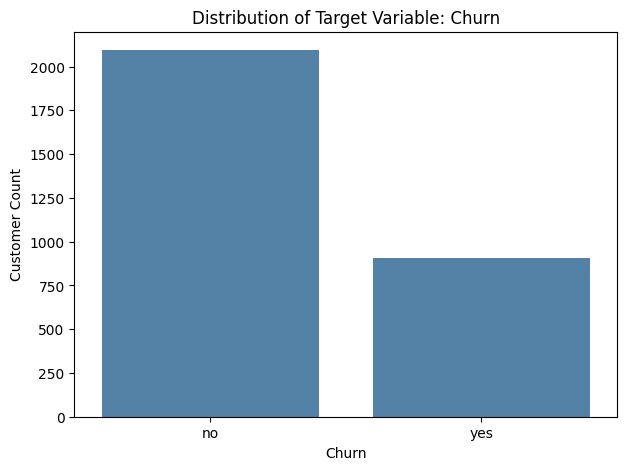

In [137]:
# Analyze the target variable
target_summary = analyzer.analyze_target()

The `analyze_target()` method is used to examine the distribution of the target variable (Churn). More specifically, it computes:
- The absolute count of each class using value_counts()
- The percentage distribution of each class using value_counts(normalize=True)
These results are then combined into a summary DataFrame, providing both the frequency and relative proportion of each class.

This step is essential for understanding the class balance of the dataset, with the majority class (no churn) representing approximately 70% of the observations, which directly influences model performance and evaluation strategy. The next thing to do is to examine the quality of the dataset by analyzing the presence of missing values.

### 3.3 Analyze and Handle Missing Values
The `analyze_missing_values()` method calculates and summarizes the number and percentage of missing values in each column of the dataset, helping to identify data quality issues that need to be addressed during preprocessing.

MISSING SUMMARY:


,missing_count,missing_percentage
YearsWithBank,287,9.57
Age,162,5.40
Savings,146,4.87
CreditScore,143,4.77
Income,135,4.50
LoanAmount,133,4.43
CustomerID,0,0.00
Gender,0,0.00
MaritalStatus,0,0.00
LoanStatus,0,0.00


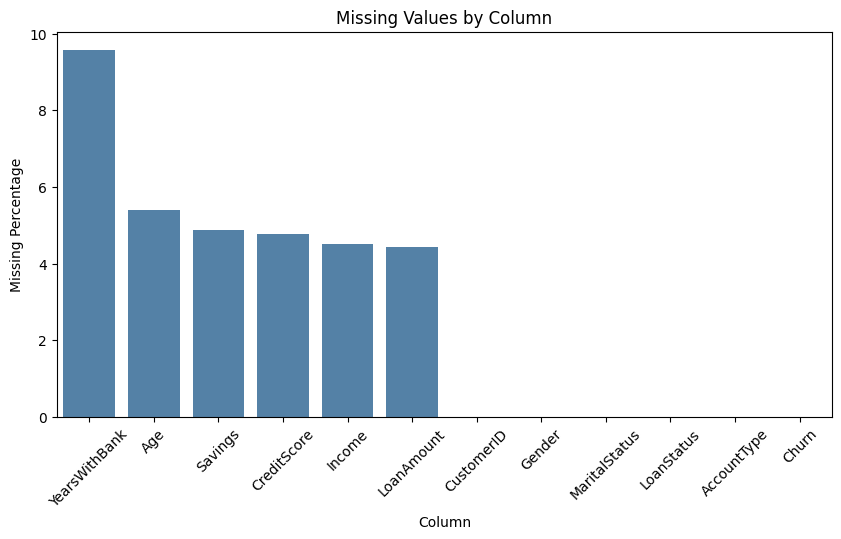

In [138]:
# Analyze missing values before imputation
missing_summary = analyzer.analyze_missing_values()

Missing values are expected and also common in real-world customer datasets. They must be handled before feature selection or modelling because most machine learning algorithms cannot process missing values directly.

The strategy used in this step is the one below:
- drop columns only if the missing-value ratio is high,
- fill numerical missing values using the median,
- fill categorical missing values using the mode.

The median is preferred over the mean for numerical columns because it is more robust to outliers.

The `handle_missing_values(drop_threshold=0.40)` improves data quality by eliminating features with excessive missingness (above 40%) and applying appropriate imputation techniques. The median for numerical variables and mode for categorical variables. This is done to preserve the dataset’s integrity and the chosen threshold ensures that only severely incomplete features are removed, while retaining as much useful information as possible.

In [139]:
# Handle missing values
no_missing_values_data = analyzer.handle_missing_values(drop_threshold=0.40)
display(no_missing_values_data)

Missing value handling completed.
Columns dropped because of missingness: []
Remaining missing values: 0


,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
0,C0001,25.0,FEMALE,single,80000.0,15000.0,600.0,50000.0,approved,joint,5.0,no
1,C0002,35.0,male,single,40000.0,5000.0,700.0,40000.0,approved,joint,10.0,no
2,C0003,35.0,female,single,100000.0,20000.0,800.0,50000.0,defaulted,checking,10.0,no
3,C0004,45.0,male,married,80000.0,20000.0,750.0,30000.0,approved,checking,5.0,no
4,C0005,45.0,male,married,40000.0,25000.0,750.0,20000.0,rejected,checking,2.0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,C2996,35.0,female,single,80000.0,15000.0,800.0,30000.0,rejected,checking,2.0,yes
2996,C2997,35.0,male,single,100000.0,25000.0,600.0,40000.0,approved,checking,5.0,no
2997,C2998,45.0,FEMALE,single,80000.0,5000.0,750.0,40000.0,approved,investment,5.0,yes
2998,C2999,45.0,FEMALE,married,80000.0,15000.0,700.0,30000.0,approved,savings,5.0,no


### 3.4 Clean Categorical Values

With `clean_categorical_values()` method, categorical values are cleaned by converting them to lowercase and removing extra spaces. It is an important step as from the `head()` method in 3.1 even, it was evident that the `Gender` column especially, but possibly others two, have different cased values with the same meaning. This is important because values such as `Male`, `male`, and ` male ` may represent the same category but would be treated as different values by Python if they are not standardized.

In [140]:
# Clean categorical values
data_cleaned_categorical = analyzer.clean_categorical_values()
display(data_cleaned_categorical)

Categorical value cleaning completed.


,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
0,c0001,25.0,female,single,80000.0,15000.0,600.0,50000.0,approved,joint,5.0,no
1,c0002,35.0,male,single,40000.0,5000.0,700.0,40000.0,approved,joint,10.0,no
2,c0003,35.0,female,single,100000.0,20000.0,800.0,50000.0,defaulted,checking,10.0,no
3,c0004,45.0,male,married,80000.0,20000.0,750.0,30000.0,approved,checking,5.0,no
4,c0005,45.0,male,married,40000.0,25000.0,750.0,20000.0,rejected,checking,2.0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,c2996,35.0,female,single,80000.0,15000.0,800.0,30000.0,rejected,checking,2.0,yes
2996,c2997,35.0,male,single,100000.0,25000.0,600.0,40000.0,approved,checking,5.0,no
2997,c2998,45.0,female,single,80000.0,5000.0,750.0,40000.0,approved,investment,5.0,yes
2998,c2999,45.0,female,married,80000.0,15000.0,700.0,30000.0,approved,savings,5.0,no


### 3.5 Explore Data Characteristics

After missing values have been handled and categorical values have been cleaned, the next step is to separate numerical and categorical columns. This step helps in understanding which columns can be analysed directly using numerical statistics and which columns require categorical analysis.

In [141]:
# Explore numerical and categorical characteristics
analyzer.explore_data_characteristics()

Numerical columns:


['Age', 'Income', 'Savings', 'CreditScore', 'LoanAmount', 'YearsWithBank']

Categorical columns:


['CustomerID', 'Gender', 'MaritalStatus', 'LoanStatus', 'AccountType', 'Churn']


CustomerID:


...

LoanStatus
approved     1793
rejected      920
defaulted     287
Name: count, dtype: int64


AccountType:


AccountType
savings       1236
checking       862
investment     601
joint          301
Name: count, dtype: int64


Churn:


Churn
no     2094
yes     906
Name: count, dtype: int64

### 3.6 Visualize Numeric and Categorical Distributions

Univariate analysis helps in understanding each feature independently. 

For numerical variables, histograms show the shape of the distribution, including skewness and possible unusual values. For categorical variables, bar charts show how frequently each category appears. This step is important before outlier detection and feature selection, because it provides a visual understanding of the raw patterns in the data.

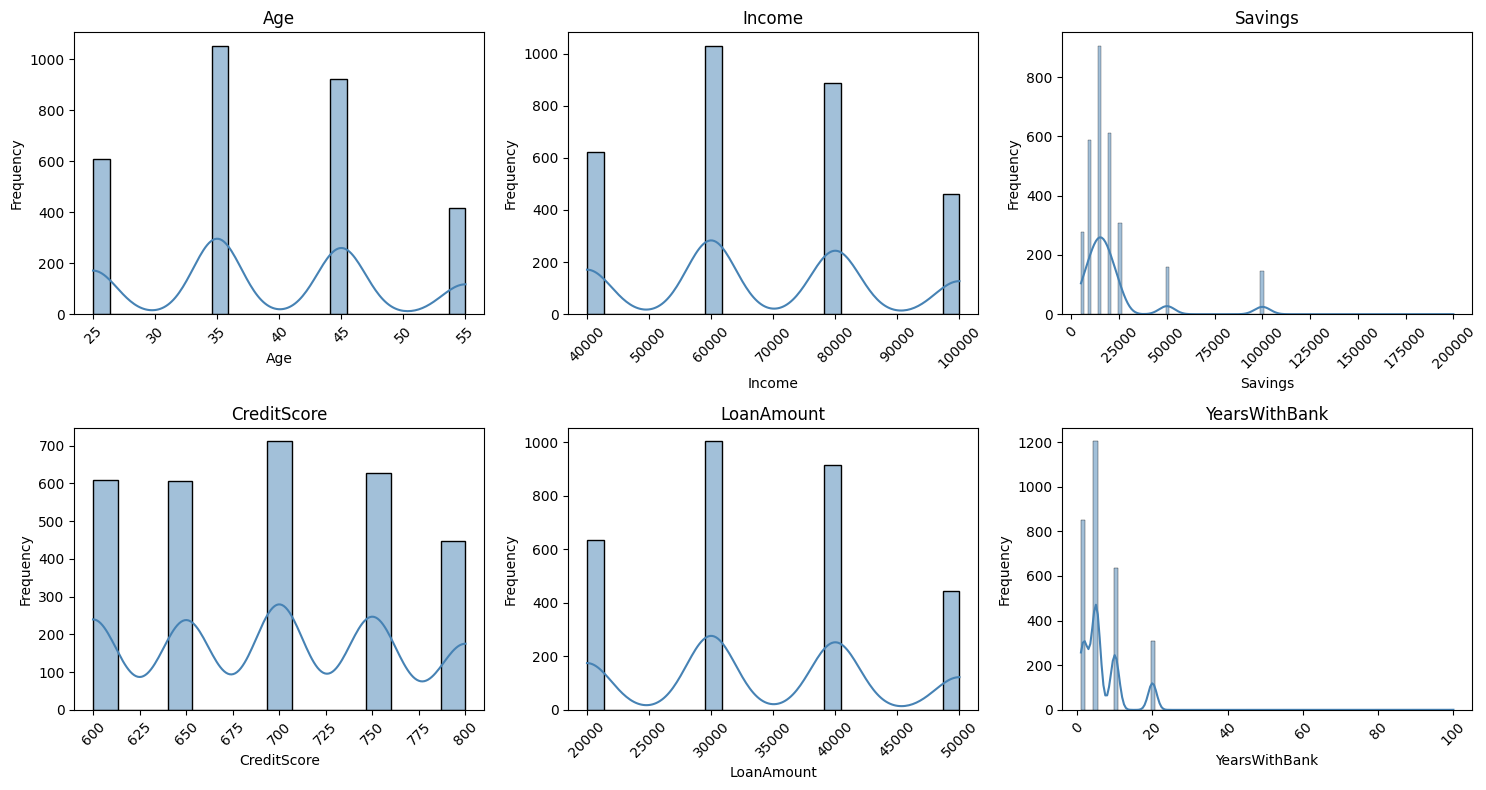

In [142]:
# Plot numerical distributions
analyzer.plot_numeric_distributions()

The histograms provide insight into the distribution, spread and potential irregularities of each numerical feature. The distribution of `Age` appears discrete and multi-modal, with clear peaks around specific values (e.g., 25, 35, 45, 55), which suggests that age may have been recorded in grouped intervals rather than as a continuous variable. The `Income` variable also shows a discrete distribution with distinct clusters, indicating predefined income brackets. The relatively balanced spread across these groups suggests that income may provide useful segmentation information for predicting churn. The `Savings` distribution is right-skewed, with most customers having lower savings and a few having significantly higher values. This skewness can indicate heterogeneity in customer financial behavior and suggests the presence of potential high-value customers. The `CreditScore` variable appears discrete with a limited number of unique values, showing multiple peaks. This suggests that credit scores are also grouped into categories rather than measured continuously, which may reduce its granularity as a predictive feature. The `LoanAmount` distribution is fairly symmetric but discrete, with values concentrated around specific loan sizes. This could mean standardized loan offerings, which may limit variability but still provide useful information when combined with other financial features. The `YearsWithBank` variable is strongly right-skewed, with most customers having short tenures.

The numerical features generally show discrete distributions with limited unique values, suggesting that many variables are grouped or categorized rather than fully continuous. Additionally, the presence of skewness and potential outliers, particularly in savings and years with the bank, highlights the need for careful preprocessing, including transformation and outlier handling.

These observations provide important guidance for the next stages of the analysis, particularly in terms of outlier treatment, feature transformation, and the selection of appropriate modeling techniques.

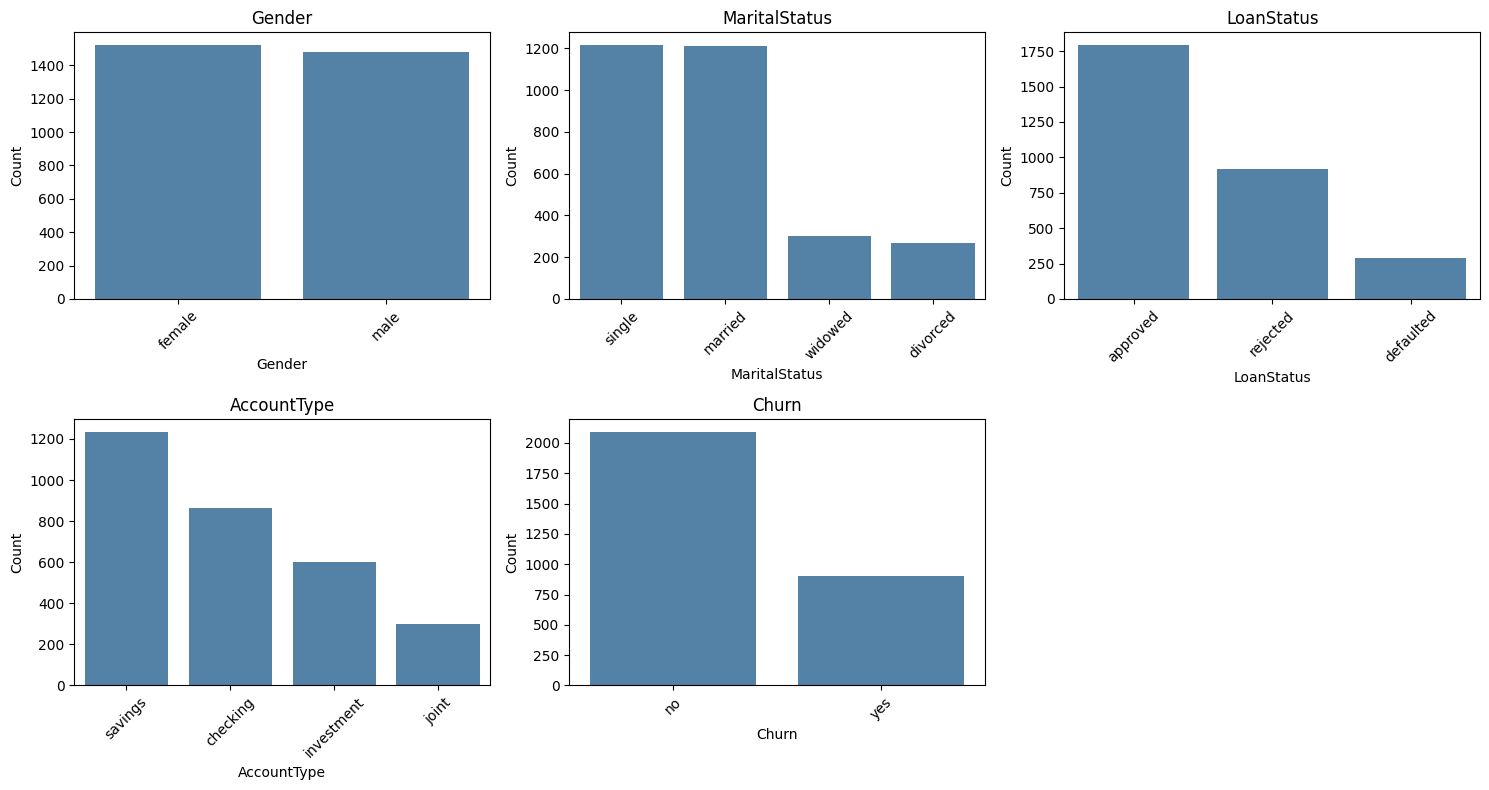

In [143]:
# Plot categorical distributions
analyzer.plot_categorical_distributions()

The bar charts show the frequency distribution of each categorical variable, providing insight into class balance and potential predictive relevance. The distribution of `Gender` is relatively balanced, with similar counts for male and female customers, which suggests that gender alone may not be a strong predictor of churn, although interactions with other features may still be informative. The `MaritalStatus` variable shows that the majority of customers are either single or married, while widowed and divorced categories are significantly less frequent. The imbalance across categories may influence model learning, and less frequent categories may contribute less to predictive performance. For the `LoanStatus` feature the majority of the samples is for approved loans, followed by rejected and a smaller number of defaulted loans. This indicates that most customers successfully obtain loans, while defaults are relatively rare. However, defaulted or rejected loans may be strongly associated with churn due to financial distress of these customers. The `AccountType` variable shows a non-uniform distribution, with savings accounts being the most common, followed by checking, investment, and joint accounts. This variation suggests that account type may capture different levels of customer engagement and financial behavior, potentially making it a useful predictive feature. The `Churn` variable confirms a class imbalance, with a higher proportion of customers not churning compared to those who do. This reinforces the need to carefully evaluate model performance using appropriate metrics, as discussed earlier.

The categorical features generally showcase low cardinality and interpretable distributions, making them suitable for encoding and inclusion in predictive models. However, the presence of imbalanced categories and uneven distributions suggests that some features may carry more predictive power than others.

These observations highlight the importance of understanding category distributions, as they influence both feature encoding strategies and the model’s ability to learn meaningful patterns.

### 3.7 Visualize Relationships with the Target Variable

Bivariate analysis studies the relationship between each feature and the target variable.

For numerical variables, boxplots show whether customers who churn have different distributions compared with customers who do not churn. For categorical variables, normalized bar charts show the proportion of churn inside each category. This step can prove helpful when identifying potentially useful predictors before formal feature selection.

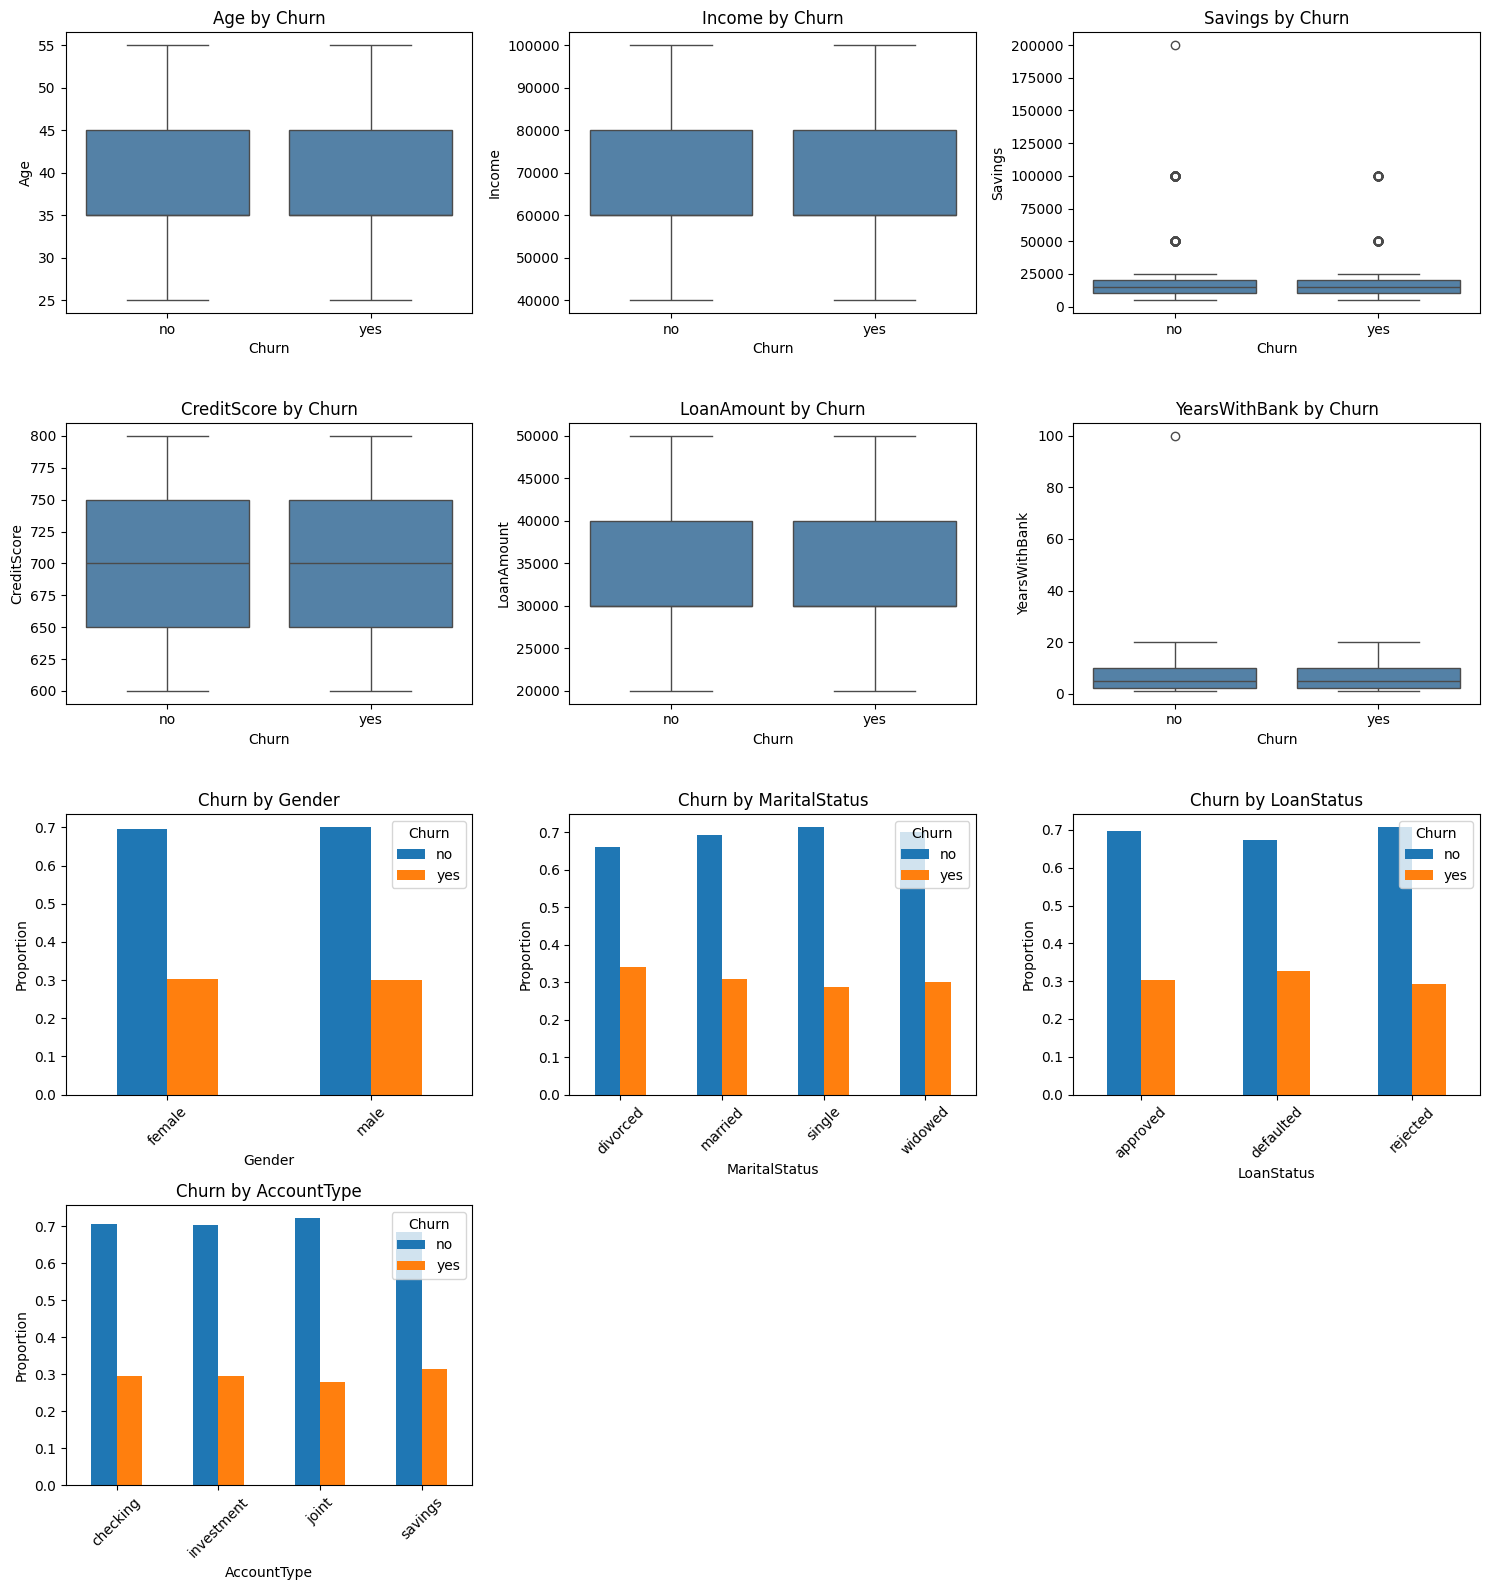

In [144]:
# Plot relationships between each feature and the target
analyzer.plot_target_relationships()

The boxplots showcase the relationship between each numerical feature and the target variable, providing insight into how feature distributions differ between customers who churn and those who do not. For the `Age` variable, both churn and non-churn groups show very similar distributions, with overlapping medians and ranges, suggesting that age alone may not be a strong differentiating factor. A similar pattern is observed for `Income`, where both groups show nearly identical distributions, indicating limited predictive power of income as an isolated feature. In the case of `Savings`, both groups are right-skewed with several high-value outliers, although churned customers appear to have slightly lower median savings, which may indicate a weak relationship with financial stability. The `CreditScore` distributions are also highly overlapping, suggesting minimal separation between churn and non-churn customers based on creditworthiness alone. Likewise, `LoanAmount` shows almost identical distributions across both classes, implying that loan size does not significantly influence churn behavior independently. In contrast, `YearsWithBank` exhibits noticeable skewness and the presence of extreme outliers, although the central distributions remain similar between the two groups, indicating that tenure alone may not strongly explain churn but could still contribute in combination with other features. Overall, the strong overlap across most numerical features suggests that no single variable provides clear separation between churn and non-churn customers, highlighting the need for multivariate analysis and feature selection techniques to uncover more complex relationships.

The bar charts illustrate the relationship between categorical features and the target variable `Churn`, showing the proportion of customers who churn within each category. The distribution of `Gender` shows nearly identical churn proportions for both male and female customers, indicating that gender does not appear to significantly influence churn behavior. For `MaritalStatus`, slight variations can be observed, with divorced customers showing a slightly higher churn proportion compared to other groups, while single customers appear to have slightly lower churn rates. However, these differences are relatively small, suggesting again limited standalone predictive power. In the case of `LoanStatus`, customers with defaulted loans exhibit a somewhat higher churn proportion compared to those with approved or rejected loans, which may indicate a relationship between financial difficulty and customer attrition. The `AccountType` feature also shows minor variation, with savings accounts displaying a slightly higher churn proportion compared to other account types, while joint accounts appear to have the lowest churn rate. Overall, although some categories exhibit subtle differences, the proportions remain relatively similar across most groups, indicating that no single categorical feature provides strong separation between churn and non-churn customers. This suggests that, similar to the numerical features, the predictive power of categorical variables is likely to emerge through interactions and combined effects rather than individual influence.

### 3.8 Correlation Heatmap

The correlation heatmap is used to identify linear relationships between numerical variables.

High correlation between input features can indicate redundancy. Redundant features may not add new information and can make the model harder to interpret. Therefore, correlation analysis is also used later as one of the formal feature selection methods.

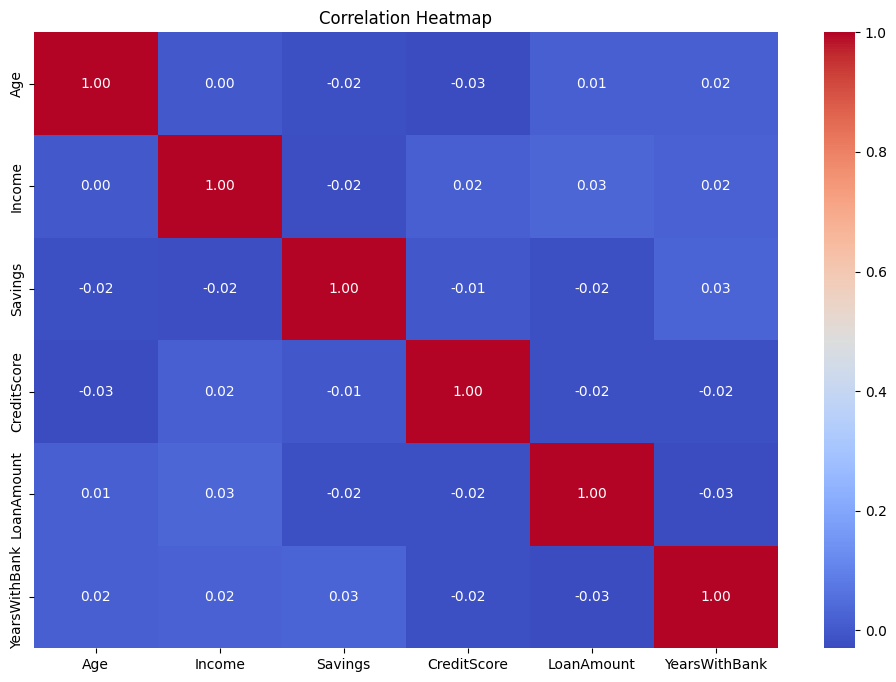

In [145]:
# Plot correlation heatmap
analyzer.plot_correlation_heatmap()

The correlation heatmap shows that all numerical features exhibit extremely low pairwise correlation values, with most coefficients close to zero. This indicates the absence of strong linear relationships between variables and suggests that multicollinearity is not a concern in this dataset. As a result, the features appear to provide largely independent information, which is beneficial for model stability and reduces the risk of redundancy. However, the lack of strong correlations also implies that meaningful patterns in the data are unlikely to be captured through simple linear relationships between features. This observation supports earlier findings from the univariate and bivariate analysis, where individual variables did not show clear separation between churn and non-churn groups. Consequently, more advanced techniques such as feature selection will be necessary to capture complex, non-linear interactions that may drive customer churn.

### 3.9 Detect and Handle Outliers

Outliers are detected using the IQR method.

The IQR method defines outliers as observations below:

`Q1 - 1.5 * IQR`

or above:

`Q3 + 1.5 * IQR`

Instead of removing rows, the extreme numerical values are clipped to the lower and upper IQR bounds. This approach reduces the impact of extreme values while preserving the number of observations.

In [146]:
# Detect outliers
outlier_summary = analyzer.detect_outliers()

# Handle outliers using clipping
data_without_outliers = analyzer.handle_outliers()
display(data_without_outliers)

OUTLIER SUMMARY:


,column,outlier_count,outlier_percentage,lower_bound,upper_bound
0,Age,0,0.00,20.0,60.0
1,Income,0,0.00,30000.0,110000.0
2,Savings,305,10.17,-5000.0,35000.0
3,CreditScore,0,0.00,500.0,900.0
4,LoanAmount,0,0.00,15000.0,55000.0
5,YearsWithBank,1,0.03,-10.0,22.0


Outlier handling completed. Clipped columns: ['Savings', 'YearsWithBank']


,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
0,c0001,25.0,female,single,80000.0,15000.0,600.0,50000.0,approved,joint,5.0,no
1,c0002,35.0,male,single,40000.0,5000.0,700.0,40000.0,approved,joint,10.0,no
2,c0003,35.0,female,single,100000.0,20000.0,800.0,50000.0,defaulted,checking,10.0,no
3,c0004,45.0,male,married,80000.0,20000.0,750.0,30000.0,approved,checking,5.0,no
4,c0005,45.0,male,married,40000.0,25000.0,750.0,20000.0,rejected,checking,2.0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,c2996,35.0,female,single,80000.0,15000.0,800.0,30000.0,rejected,checking,2.0,yes
2996,c2997,35.0,male,single,100000.0,25000.0,600.0,40000.0,approved,checking,5.0,no
2997,c2998,45.0,female,single,80000.0,5000.0,750.0,40000.0,approved,investment,5.0,yes
2998,c2999,45.0,female,married,80000.0,15000.0,700.0,30000.0,approved,savings,5.0,no


The `detect_outliers()` method identifies extreme values in numerical features using the Interquartile Range (IQR) method. For each numerical column, it calculates the first quartile (Q1) and third quartile (Q3), computes the IQR as the difference between them, and defines outliers as values falling below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`. The method then summarizes the number and percentage of outliers for each feature, along with the calculated lower and upper bounds, providing a clear overview of where extreme values occur in the dataset.

The `handle_outliers()` method addresses these extreme values by applying a clipping strategy rather than removing observations. Specifically, values that fall outside the IQR bounds are replaced with the corresponding lower or upper threshold. This approach reduces the influence of outliers while preserving all data points, ensuring that the dataset size remains unchanged and preventing potential loss of information.

This combination of detection and clipping provides a balanced approach, reducing the impact of extreme values while maintaining the integrity and completeness of the dataset.

### 3.10 Feature Selection

Feature selection is one of the most important parts of the data processing. The goal is to reduce the dataset to the most useful predictors while keeping the final dataset simple and interpretable.

The final CSV is intentionally limited to:

- 6 selected features,
- plus the target column `Churn`.

This gives a compact final dataset with 7 columns in total.

The notebook applies the first three feature selection methods from the course material:

1. **Variance Thresholding**  
   Removes features that have very low variance and therefore provide little information.

2. **Correlation Analysis**  
   Removes highly correlated features to reduce redundancy.

3. **Information Gain**  
   Ranks the remaining features based on how much information they provide about the target variable.

The `CustomerID` column is removed before feature selection because it is an identifier, not a predictive feature.

INFORMATION GAIN SCORES:


,information_gain
LoanAmount,0.019901
Income,0.007887
MaritalStatus,0.000548
AccountType,0.000358
LoanStatus,0.000199
Gender,0.000007
Age,0.000000
Savings,0.000000
CreditScore,0.000000
YearsWithBank,0.000000


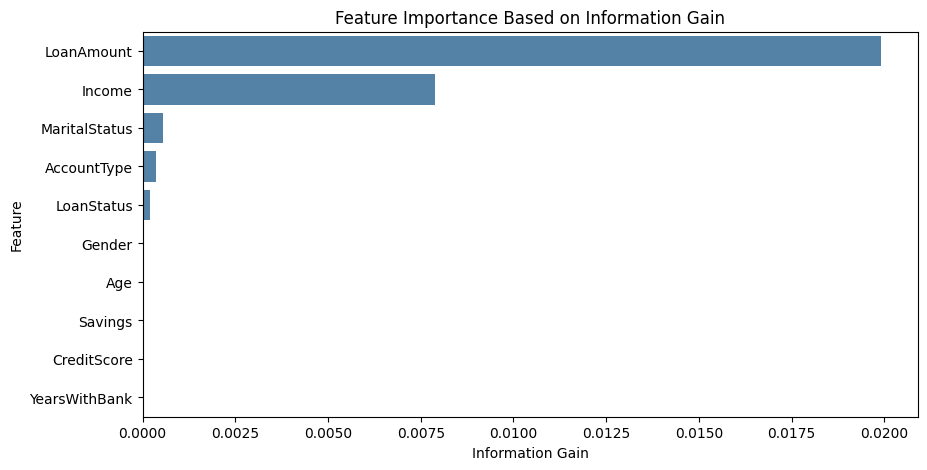

Feature selection completed.
Low-variance columns removed: []
Highly correlated columns removed: []
Selected final features: ['LoanAmount', 'Income', 'MaritalStatus', 'AccountType', 'LoanStatus', 'Gender']
Final dataset shape: (3000, 7)


,LoanAmount,Income,MaritalStatus,AccountType,LoanStatus,Gender,Churn
0,50000.0,80000.0,2,2,0,0,no
1,40000.0,40000.0,2,2,0,1,no
2,50000.0,100000.0,2,0,1,0,no
3,30000.0,80000.0,1,0,0,1,no
4,20000.0,40000.0,1,0,2,1,yes


Final dataset shape: (3000, 7)


In [147]:
# Apply feature selection
final_data_after_selection = analyzer.select_features(
    correlation_threshold=0.80,
    variance_threshold=0.01,
    use_information_gain=True,
    min_information_gain=0.0
)

# Display the first rows of the final selected dataset
display(final_data_after_selection.head())

# Display the final shape
print("Final dataset shape:", final_data_after_selection.shape)

The `select_features()` method performs a multi-step feature selection process aimed at reducing dimensionality, removing redundant or uninformative variables, and retaining only the most relevant features for predicting customer churn. The method combines statistical filtering techniques with information-theoretic ranking to ensure a robust and data-driven selection of features.

#### Step 1: Data Preparation

The method begins by validating that processed data is available and that the target column exists. It then separates the dataset into:

- **Features (`X`)**: All columns except the target and the customer identifier
- **Target (`y`)**: The `Churn` variable

The identifier column (e.g., `CustomerID`) is explicitly removed, as it does not carry predictive information.

#### Step 2: Encoding Categorical Variables

Since machine learning algorithms and feature selection techniques require numerical input, all categorical features are transformed using **Label Encoding**. Each unique category is mapped to a numerical value.

Additionally, if the target variable is categorical, it is also encoded into numerical form to ensure compatibility with the feature selection methods.

#### Step 3: Variance Thresholding

A **Variance Threshold** is applied to remove features with very low variability across observations.

- Features with variance below the specified threshold (default: `0.01`) are removed.
- Low-variance features contribute little to model learning, as they do not provide meaningful differentiation between samples.

This step helps eliminate uninformative features early in the pipeline.

#### Step 4: Correlation Filtering

Next, the method computes the **pairwise correlation matrix** of the remaining features.

- If two features exhibit high correlation (above the threshold, default: `0.80`), one of them is removed.
- This step reduces **multicollinearity**, which can negatively impact model stability and interpretability.

The approach ensures that redundant features are eliminated while preserving as much unique information as possible.

#### Step 5: Information Gain

To evaluate the predictive relevance of each feature, the method computes **Information Gain** between each feature and the target variable.

- Information Gain measures how much knowing a feature reduces uncertainty about the target.
- Unlike correlation, it captures **non-linear relationships**, making it particularly useful for complex datasets.

The resulting scores are:
- Displayed in tabular form
- Visualized using a bar chart for interpretability

#### Step 6: Feature Selection Based on Information Gain

At this stage, features are selected based on their **Information Gain scores**.

Instead of selecting a fixed number of features, the method retains all features that satisfy the condition:

Information Gain > min_information_gain

By default:

min_information_gain = 0.0

This means:
- Features that provide **any positive predictive signal** are kept  
- Features with zero information gain are removed, as they do not contribute to predicting the target variable  

This approach ensures that feature selection is **data-driven rather than arbitrary**, allowing the model to retain all informative features while discarding those that offer no predictive value.

#### Step 7: Final Dataset Construction

The selected features are combined with the original target variable to form the final dataset.

- The dataset is updated internally (`processed_data` and `final_data`)
- A report is generated containing:
- Removed low-variance features  
- Removed highly correlated features  
- Information gain scores  
- Final selected features  
- Final dataset shape  

This ensures full transparency and traceability of the feature selection process.

#### Overall

The feature selection process systematically removes irrelevant and redundant features while preserving those that contribute meaningful predictive information. By combining variance filtering, correlation analysis, and information gain, the method ensures a balanced approach that captures both linear and non-linear relationships.

Key Advantages:

- Reduces overfitting by eliminating noise and redundancy  
- Improves model performance and interpretability  
- Avoids arbitrary feature selection by relying on data-driven thresholds  
- Captures complex relationships through information gain

The result is a clean, compact, and informative feature set, optimized for building predictive models that can effectively identify customer churn patterns.

### 3.11 Final Feature Selection Interpretation

The selected features are the columns that remain after the three feature selection stages.

The interpretation is important because feature selection should not be treated as a black-box procedure. The final selected columns are the ones that survived low-variance filtering, redundancy filtering, and Information Gain ranking.

This makes the final dataset more efficient and easier to explain.

In [148]:
# Display selected features from the report
selected_features = analyzer.get_report()["selected_features"]

print("Selected features:")
for feature in selected_features:
    print("-", feature)

Selected features:
- LoanAmount
- Income
- MaritalStatus
- AccountType
- LoanStatus
- Gender


### 3.12 Save the Final Processed Dataset

The final processed dataset is saved as a CSV file. This exported file contains only the selected features and the target variable.

This means the output is ready to be used in a future Machine Learning pipeline.

In [149]:
# Save the final processed dataset
analyzer.save_processed_data("bank_customer_processed.csv")

Final dataset saved successfully as: bank_customer_processed.csv


## 4. Final Report Summary

The report dictionary stores the most important results from the analysis. This includes:
- the original dataset shape,
- target distribution,
- missing value summary,
- columns dropped due to missingness,
- outlier summary,
- columns clipped during outlier handling,
- columns removed by variance thresholding,
- columns removed by correlation analysis,
- Information Gain scores,
- final selected features,
- final dataset shape.

This makes the notebook reproducible and auditable because the important decisions are stored in one place.

In [150]:
# Display the final report keys
report = analyzer.get_report()

print("Report keys:")
for key in report.keys():
    print("-", key)

print("\nFinal selected features:")
display(report["selected_features"])

print("\nFinal dataset shape:")
display(report["final_shape"])

Report keys:
- loaded_shape
- target_summary
- missing_summary
- dropped_missing_columns
- missing_after_imputation
- numeric_columns
- categorical_columns
- outlier_summary
- clipped_outlier_columns
- low_variance_columns
- high_correlation_columns
- information_gain_scores
- label_encoders
- target_encoder
- selected_features
- final_shape

Final selected features:


['LoanAmount',
 'Income',
 'MaritalStatus',
 'AccountType',
 'LoanStatus',
 'Gender']


Final dataset shape:


(3000, 7)

## 5. Conclusion

This notebook followed a complete data analysis workflow for a customer churn dataset.

The project started with raw data inspection and continued through missing value handling, categorical cleaning, exploratory analysis, outlier handling, feature selection and the final dataset export ready to be used from a Machine Learning model.

The final dataset contains 6 selected features plus the target column `Churn`. This is suitable for future Machine Learning work because it is smaller, cleaner, and easier to interpret than the original dataset.

The feature selection process was based on three academically standard methods:
- Variance Thresholding,
- Correlation Analysis,
- and Information Gain.